# Evaluation of weather conditions

## Lessons learned — superseded by `eval_weather_robustness.py` (updated 2026-06-18)

This manual notebook is **superseded** by the reproducible, multi-model script
`workflows/scripts/eval_weather_robustness.py`, which seeds weather onto the **held-out
flight-level test split**, scores several models at once, and emits a JSON comparison.

- **Pure OpenCV, not albumentations.** AlbumentationsX's `albucore` SIMD backend corrupts async
  CUDA work on this stack, so weather effects now live in `workflows/scripts/weather_aug.py`
  (OpenCV/NumPy). `albumentations` is uninstalled — the `A.Compose(...)` cells below won't run.
- **Snow is the decisive condition** (this notebook only covered clear/rain/fog/haze). On the
  held-out test split, **snow blinds clear-trained models** — serving yolo26s mAP@0.5 ~0.03,
  old nano ~0.00, even the old `yolo26s-weather-aug` (train-9, rain/fog/haze only) ~0.08 — while
  the **weather-trained nano holds ~0.82**. Snow speckle mimics white lamps, so the model must
  train on it. Rain/fog/haze degrade all models far less (synthetic fog is a contrast veil).
- **Season / time-of-day = colour-TEMPERATURE (warm/cool) tints**, NOT hue/saturation jitter
  (colour is the class). See the `warm`/`cool` conditions in `weather_aug.py`.

Reproduce current numbers, e.g.:

    .venv/Scripts/python workflows/scripts/eval_weather_robustness.py       --data data/datasets/papi-2class-detection-flightsplit/data.yaml --split test       --conditions clear rain fog haze snow --severity heavy       --models nano-weather=<run>/weights/best.pt small=models/serving/best.pt       --out output/weather-robustness.json


## Imports

In [17]:
import os
import sys
import cv2
import shutil
from pathlib import Path
import time
from collections import deque, Counter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

# Weather aug is now pure OpenCV (workflows/scripts/weather_aug.py); albumentations is uninstalled
# (its albucore backend breaks async CUDA training — see the lessons cell at top). Prefer the
# reproducible script workflows/scripts/eval_weather_robustness.py over the legacy cells below.
sys.path.insert(0, os.path.join("..", "scripts"))
from weather_aug import apply_weather, CONDITIONS  # OpenCV weather/tints  # noqa: E402

try:
    import albumentations as A  # legacy only; if absent, the A.Compose(...) cells below won't run
except ImportError:
    A = None


## Creating Validation sets with weather albumentations

In [2]:
valid_path = Path("PAPI_Split/valid")

image_dir = valid_path / "images"
label_dir = valid_path / "labels"

output_root = Path("PAPI_Weather_Valid")

transforms = {
    "clear": A.Compose([]),

    "rain": A.Compose([
        A.RandomRain(
            slant_range=(-10, 10),
            drop_length=20,
            drop_width=1,
            blur_value=3,
            brightness_coefficient=0.9,
            p=1.0
        )
    ]),

    "fog": A.Compose([
        A.RandomFog(
            fog_coef_range=(0.3, 0.6),
            alpha_coef=0.08,
            p=1.0
        )
    ]),

    "haze": A.Compose([
        A.RandomFog(
            fog_coef_range=(0.1, 0.25),
            alpha_coef=0.04,
            p=1.0
        )
    ]),
}

In [ ]:
for condition, transform in transforms.items():

    out_img_dir = output_root / condition / "images"
    out_lbl_dir = output_root / condition / "labels"

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_path in image_dir.glob("*"):

        image = cv2.imread(str(img_path))

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        transformed = transform(image=image)
        aug_img = transformed["image"]

        aug_img = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)

        cv2.imwrite(
            str(out_img_dir / img_path.name),
            aug_img
        )

        label_path = label_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            shutil.copy(
                label_path,
                out_lbl_dir / label_path.name
            )

print("Finished generating weather validation datasets.")

Finished generating weather validation datasets.


: 

## Evaluating on latest model

In [2]:
model = YOLO("runs/detect/train-9/weights/best.pt")

In [4]:
conditions = ["clear", "rain", "fog", "haze"]

results = {}

for condition in conditions:
    metrics = model.val(
        data=f"weather_yaml/{condition}.yaml",
        imgsz=640,
        verbose=False
    )

    results[condition] = {
        "mAP50": metrics.box.map50,
        "mAP50_95": metrics.box.map,
        "precision": metrics.box.mp,
        "recall": metrics.box.mr,
    }

print(results)

Ultralytics 8.4.51  Python-3.11.7 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 1.11.7 ms, read: 308.7224.7 MB/s, size: 2861.7 KB)
val: Scanning D:\School\Howest\Industry Project\Git data\data\PAPI_Weather_Valid\clear\labels... 638 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 517.6it/s 1.2s0.1s
val: New cache created: D:\School\Howest\Industry Project\Git data\data\PAPI_Weather_Valid\clear\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 3.7it/s 10.9s0.1s
                   all        638       2547      0.902      0.846      0.949      0.637
Speed: 1.4ms preprocess, 5.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\School\Howest\Industry Project\Git data\data\runs\detect\val-12
Ultralytics 8.4.51  Python-3.11.7 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.90.4 ms, r

In [5]:
for condition, metrics in results.items():
    print(f"Condition: {condition}")
    print(f"Metrics: {metrics}")

Condition: clear
Metrics: {'mAP50': np.float64(0.9485508360440531), 'mAP50_95': np.float64(0.6366777197206893), 'precision': np.float64(0.9018746171758589), 'recall': np.float64(0.8462807032528732)}
Condition: rain
Metrics: {'mAP50': np.float64(0.946723140436178), 'mAP50_95': np.float64(0.6278871395027379), 'precision': np.float64(0.8911166743730918), 'recall': np.float64(0.8538892498538061)}
Condition: fog
Metrics: {'mAP50': np.float64(0.6634746618509517), 'mAP50_95': np.float64(0.27126112496221094), 'precision': np.float64(0.7020779350799067), 'recall': np.float64(0.6325079265842004)}
Condition: haze
Metrics: {'mAP50': np.float64(0.6818083978430496), 'mAP50_95': np.float64(0.292675666985005), 'precision': np.float64(0.7564973922997258), 'recall': np.float64(0.6063101936617097)}


## Graphs & Plots

In [19]:
results = {
    "clear": {
        "mAP50": 0.9485508360440531,
        "mAP50_95": 0.6366777197206893,
        "precision": 0.9018746171758589,
        "recall": 0.8462807032528732
    },
    "rain": {
        "mAP50": 0.946723140436178,
        "mAP50_95": 0.6278871395027379,
        "precision": 0.8911166743730918,
        "recall": 0.8538892498538061
    },
    "fog": {
        "mAP50": 0.6634746618509517,
        "mAP50_95": 0.27126112496221094,
        "precision": 0.7020779350799067,
        "recall": 0.6325079265842004
    },
    "haze": {
        "mAP50": 0.6818083978430496,
        "mAP50_95": 0.292675666985005,
        "precision": 0.7564973922997258,
        "recall": 0.6063101936617097
    }
}

df = pd.DataFrame(results).T
df

,mAP50,mAP50_95,precision,recall
clear,0.948551,0.636678,0.901875,0.846281
rain,0.946723,0.627887,0.891117,0.853889
fog,0.663475,0.271261,0.702078,0.632508
haze,0.681808,0.292676,0.756497,0.606310


<Figure size 1000x600 with 0 Axes>

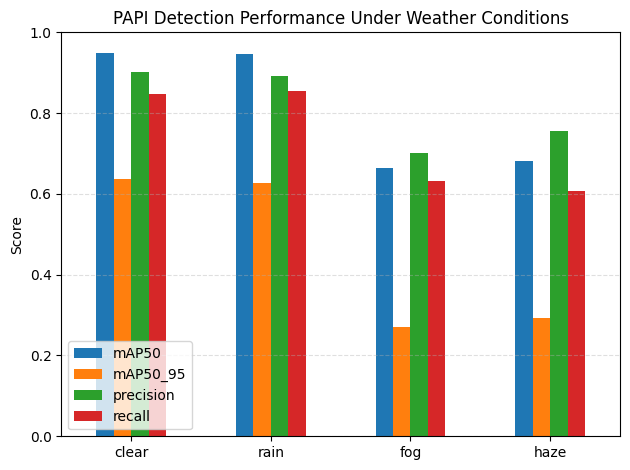

In [25]:
%matplotlib inline
plt.figure(figsize=(10,6))

df[["mAP50", "mAP50_95", "precision", "recall"]].plot(
    kind="bar"
)

plt.title("PAPI Detection Performance Under Weather Conditions")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

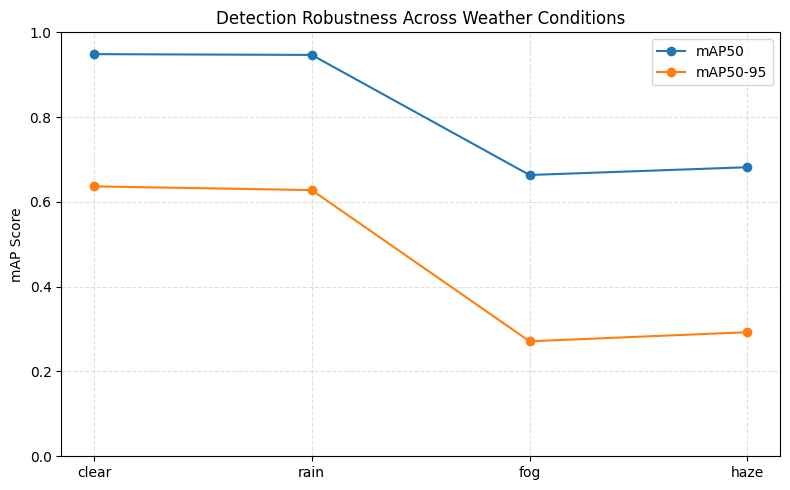

In [26]:
%matplotlib inline
plt.figure(figsize=(8,5))

plt.plot(df.index, df["mAP50"], marker="o", label="mAP50")
plt.plot(df.index, df["mAP50_95"], marker="o", label="mAP50-95")

plt.title("Detection Robustness Across Weather Conditions")
plt.ylabel("mAP Score")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

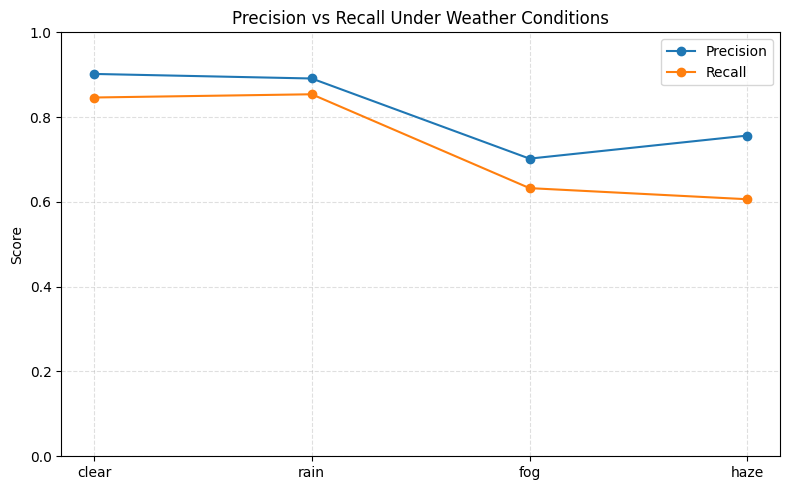

In [27]:
%matplotlib inline
plt.figure(figsize=(8,5))

plt.plot(df.index, df["precision"], marker="o", label="Precision")
plt.plot(df.index, df["recall"], marker="o", label="Recall")

plt.title("Precision vs Recall Under Weather Conditions")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

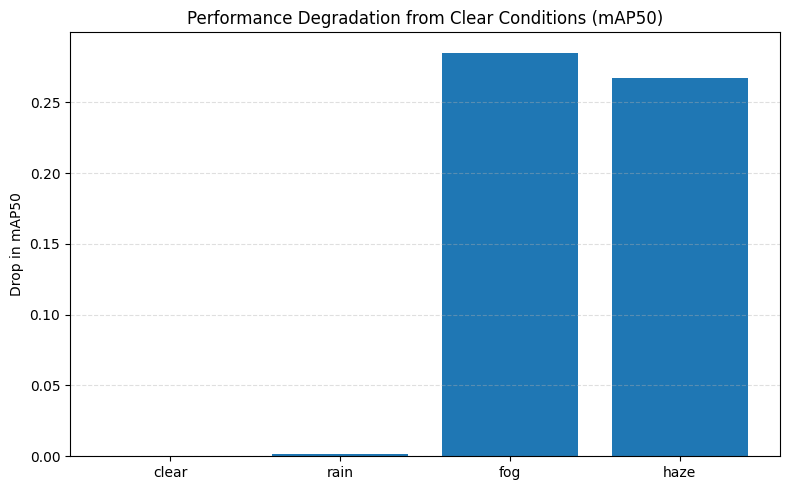

In [28]:
%matplotlib inline
baseline = df.loc["clear", "mAP50"]
drop = baseline - df["mAP50"]

plt.figure(figsize=(8,5))
plt.bar(df.index, drop)

plt.title("Performance Degradation from Clear Conditions (mAP50)")
plt.ylabel("Drop in mAP50")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## No rain

In [12]:
# -----------------------
# CONFIG
# -----------------------
video_path = "output.avi"
model_path = r"runs\detect\train-9\weights\best.pt"
output_path = "output_annotated_yolo_no_rain.avi"

history = deque(maxlen=5)

# -----------------------
# LOAD MODEL (YOLO PT)
# -----------------------
model = YOLO(model_path)

# -----------------------
# VIDEO
# -----------------------
cap = cv2.VideoCapture(video_path)

frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_w, frame_h))

# -----------------------
# CLASS NAMES
# -----------------------
class_names = {0: "papi_red", 1: "papi_white"}

# -----------------------
# MAIN LOOP WITH TRACKING
# -----------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    start_time = time.time()

    # -----------------------
    # TRACKING (ByteTrack default)
    # -----------------------
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        conf=0.4,
        verbose=False
    )

    red_count = 0
    white_count = 0

    r = results[0]

    # -----------------------
    # DRAW DETECTIONS
    # -----------------------
    if r.boxes is not None:
        for box in r.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            track_id = int(box.id[0]) if box.id is not None else -1

            label = class_names.get(cls_id, str(cls_id))

            # COUNT LIGHTS
            if cls_id == 0:
                red_count += 1
            elif cls_id == 1:
                white_count += 1

            # COLOR
            color = (0, 255, 0) if cls_id == 1 else (0, 0, 255)

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            text = f"ID:{track_id} {label} {conf:.2f}"
            cv2.putText(frame, text, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # -----------------------
    # FPS
    # -----------------------
    end_time = time.time()
    inference_fps = 1 / (end_time - start_time + 1e-6)

    cv2.putText(frame,
                f"INF FPS: {inference_fps:.2f}",
                (20, 150),
                cv2.FONT_HERSHEY_SIMPLEX,
                3,
                (0, 0, 255),
                2)

    # -----------------------
    # PAPI LOGIC
    # -----------------------
    total = red_count + white_count

    if total == 0:
        state = "NO SIGNAL"

    else:
        white_ratio = white_count / total

        if white_ratio >= 0.85:
            state = "TOO HIGH (4W)"
        elif 0.60 <= white_ratio < 0.85:
            state = "SLIGHTLY HIGH"
        elif 0.40 <= white_ratio < 0.60:
            state = "ON GLIDE PATH (2R2W)"
        elif 0.15 <= white_ratio < 0.40:
            state = "SLIGHTLY LOW"
        else:
            state = "TOO LOW (4R)"

    # -----------------------
    # SMOOTHING
    # -----------------------
    history.append(state)
    final_state = Counter(history).most_common(1)[0][0]

    cv2.putText(frame,
                f"PAPI: {final_state}",
                (20, 300),
                cv2.FONT_HERSHEY_SIMPLEX,
                4,
                (255, 255, 0),
                4)

    # -----------------------
    # WRITE FRAME
    # -----------------------
    out.write(frame)

cap.release()
out.release()

print("DONE ✔")
print("Saved to:", output_path)

DONE ✔
Saved to: output_annotated_yolo_no_rain.avi


## Rain video metric

In [ ]:
rain_transform = A.Compose([
    A.RandomRain(
        drop_length=10,
        drop_width=1,
        blur_value=1,
        brightness_coefficient=0.97,
        p=1.0
    )
])

input_video = "output.avi"
output_video = "output_annotated_rain.avi"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"XVID")
writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert BGR -> RGB ONLY for Albumentations
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    rainy = rain_transform(image=rgb)["image"]

    # Back to BGR BEFORE YOLO (important for consistency)
    rainy_bgr = cv2.cvtColor(rainy, cv2.COLOR_RGB2BGR)

    results = model.predict(rainy_bgr, verbose=False)

    annotated = results[0].plot()  # BGR output

    writer.write(annotated)

    frame_count += 1
    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames")

cap.release()
writer.release()

print("Done:", output_video)

C:\Users\maxim\AppData\Local\Temp\ipykernel_18136\1840823151.py:2: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(


Done: output_annotated_rain.avi


## Heavier rain

In [15]:
rain_transform = A.Compose([
    A.RandomRain(
        slant_lower=-20,
        slant_upper=20,
        drop_length=25,      # longer streaks = heavier rain
        drop_width=2,
        blur_value=3,        # more blur = heavier rain
        brightness_coefficient=0.85,  # darker scene
        rain_type="heavy",
        p=1.0
    )
])

input_video = "output.avi"
output_video = "output_annotated_heavy_rain.avi"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"XVID")
writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert BGR -> RGB ONLY for Albumentations
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    rainy = rain_transform(image=rgb)["image"]

    # Back to BGR BEFORE YOLO (important for consistency)
    rainy_bgr = cv2.cvtColor(rainy, cv2.COLOR_RGB2BGR)

    results = model.predict(rainy_bgr, verbose=False)

    annotated = results[0].plot()  # BGR output

    writer.write(annotated)

    frame_count += 1
    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames")

cap.release()
writer.release()

print("Done:", output_video)

C:\Users\maxim\AppData\Local\Temp\ipykernel_18136\1323575019.py:2: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(


Done: output_annotated_heavy_rain.avi
